In [1]:
# the following is added due to a warning
import os
import json
from keras.utils import image_dataset_from_directory as LdImg
from keras.layers import SimpleRNN, Dense,Input
from keras.models import Model
from keras.saving import save_model
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
import pandas as pd
from keras.utils import plot_model

In [2]:
with open('applestock2024.json', 'r') as file:
    ReadData = json.load(file)
ReadData = ReadData["Time Series (Daily)"]    

# Pretty high effort just want to learn how to import
RawData = []
for date, values in ReadData.items():
    #Prices = np.array(list(values.values()),dtype=np.float32) # doesn't work because you can't
    # join 2 array with differrent data type together 
    RowData = [date] + list(values.values())
    RawData.append(RowData)
    
StockData = pd.DataFrame(RawData,columns=['Date', 'Open Price', 'High Price','Low Price','Close Price','Volume'])
StockData = StockData.astype({'Open Price': 'float64', 'High Price': 'float64','Low Price': 'float64', 'Close Price': 'float64', 'Volume': 'int64'})
StockData = StockData.iloc[::-1]
StockData.reset_index(drop=True, inplace=True)
# Simple way, because only close prices are needed
#for date, values in ReadData.items():
#    close_price = values["4. close"]

In [3]:
print(StockData)

           Date  Open Price  High Price  Low Price  Close Price    Volume
0    2024-01-03     184.220    185.8800     183.43       184.25  58414460
1    2024-01-04     182.150    183.0872     180.88       181.91  71983570
2    2024-01-05     181.990    182.7600     180.17       181.18  62196924
3    2024-01-08     182.085    185.6000     181.50       185.56  59144470
4    2024-01-09     183.920    185.1500     182.73       185.14  42841809
..          ...         ...         ...        ...          ...       ...
246  2024-12-24     255.490    258.2100     255.29       258.20  23234705
247  2024-12-26     258.190    260.1000     257.63       259.02  27262983
248  2024-12-27     257.830    258.7000     253.06       255.59  42355321
249  2024-12-30     252.230    253.5000     250.75       252.20  35557542
250  2024-12-31     252.440    253.2800     249.43       250.42  39480718

[251 rows x 6 columns]


In [4]:
PriceStdCal = StandardScaler()
StdClosePrice = PriceStdCal.fit_transform(StockData[['Close Price']])

In [5]:
def MovingWindow(data, slide):
    x = []
    y = []
    for i in range(len(data)-slide):
        x.append([i for i in data[i:i+slide]])
        y.append(data[i+slide])
    x = np.array(x)
    x = x.reshape(x.shape[0],x.shape[1],1)
    y = np.array(y)
    return x , y
        


In [6]:
TimeStep = 20
StdPriceSlide, StdPriceLabel = MovingWindow(StdClosePrice,TimeStep)

In [7]:
# Define the input shape instead specify it direction in the first convolution layer
RNNInputLayer = Input(shape=(TimeStep,1))
#Add RNN layer
RNNCell = SimpleRNN(units = 5,activation="tanh")(RNNInputLayer)
# Add dense (output)layer
RNNOutputLayer = Dense(units=1,activation='linear')(RNNCell)
#RNNModel.compile(optimizer = 'adam', loss = 'mse')
# Create the RNN model
RNNModel = Model(inputs=RNNInputLayer,outputs=RNNOutputLayer)
RNNModel.compile(optimizer ='adam', loss ='mse')
RNNModel.summary()
#plot_model(RNNModel, to_file='RNNModel.png', show_shapes=True, show_layer_names=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
RNNModel.fit(StdPriceSlide,StdPriceLabel,epochs=1000,verbose=0)


In [13]:
PredictedPrice = RNNModel.predict(StdPriceSlide)
PredictedPrice = PriceStdCal.inverse_transform(PredictedPrice)
LabeledPrice = PriceStdCal.inverse_transform(StdPriceLabel)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


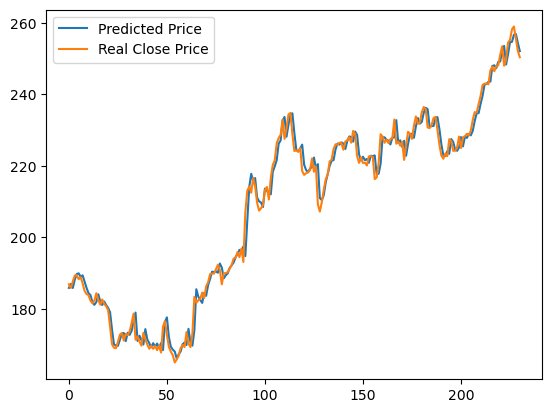

In [14]:
figure1= plt.figure()
plt.plot(PredictedPrice ,label='Predicted Price')
plt.plot(LabeledPrice, label ='Real Close Price')
plt.legend()
